# Mechanistic Interpretability Deep Dive: SAE + Ablation, and Its Sensitivity

This notebook is the most nuanced result in the paper and we present it as such:
not a clean yes/no verdict, but a genuinely mixed finding that changes shape once
we check it across seeds and folds instead of trusting a single run.

Two artifacts:

- `results/metrics/xai_mechanistic.json`: ONE run -- a sparse autoencoder (SAE)
  trained on the Transformer's last-token representation, plus an exhaustive
  head/layer ablation sweep ("ACDC-inspired", not the full automated ACDC algorithm).
- `results/metrics/xai_mechanistic_sensitivity.json`: the SAME pipeline re-run
  across 3 seeds x 2 folds = 6 independent Transformer trainings, to check whether
  the single-run findings are reproducible.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

METRICS = "../results/metrics"

with open(f"{METRICS}/xai_mechanistic.json") as f:
    mech = json.load(f)
with open(f"{METRICS}/xai_mechanistic_sensitivity.json") as f:
    sens = json.load(f)

print("xai_mechanistic.json top-level keys:", list(mech.keys()))
print("xai_mechanistic_sensitivity.json top-level keys:", list(sens.keys()))
print()
print("Sensitivity protocol:", sens["protocol"])

xai_mechanistic.json top-level keys: ['sae', 'acdc_ablation']
xai_mechanistic_sensitivity.json top-level keys: ['protocol', 'runs', 'pct_interpretable_latents_across_runs', 'n_notable_ablation_components_across_runs', 'max_ablation_z_across_runs', 'top_component_per_run', 'n_distinct_top_components', 'stable_null_finding', 'consistent_top_component_across_runs', 'verdict']

Sensitivity protocol: 3 seeds (42/43/44) x 2 folds (2022/2023) = 6 independent Transformer trainings, each re-run through the identical SAE (D_hid=4*D_model, L1=1e-3, 400 epochs) + exhaustive head/layer ablation sweep as run(). seed=42/fold=2023 reproduces run()'s exact setting.


## Part 1: the single-run SAE result

The SAE is trained on the Transformer's last-token hidden representation
(dim=64) with a 4x overcomplete hidden dimension (256 latents), L1 sparsity
penalty. A latent is called "interpretable" if its activation correlates
|r| > 0.3 with some known input feature.

In [2]:
sae = mech["sae"]
print(f"SAE: {sae['hidden_dim']} latents, input_dim={sae['input_dim']}, "
      f"L1={sae['l1_coefficient']}, trained {sae['epochs']} epochs")
print(f"Final reconstruction MSE: {sae['final_reconstruction_mse']:.5f}")
print(f"Interpretable latents (|corr| > {sae['correlation_threshold']}): "
      f"{sae['n_interpretable_latents']}/{sae['hidden_dim']} "
      f"({100*sae['n_interpretable_latents']/sae['hidden_dim']:.1f}%)")
print(f"Dead latents: {sae.get('n_dead', 'n/a')}, alive-but-uninterpretable: {sae.get('n_alive_uninterpretable', 'n/a')}")
print()
print("Verdict (single run):", sae.get("verdict", "n/a"))

SAE: 256 latents, input_dim=64, L1=0.001, trained 400 epochs
Final reconstruction MSE: 0.00676
Interpretable latents (|corr| > 0.3): 253/256 (98.8%)
Dead latents: 0, alive-but-uninterpretable: 3

Verdict (single run): 253/256 SAE latents (98.8%) have |correlation| > 0.3 with a named input feature; 0 latents are dead (activation std < 1e-6); 3 are alive but uninterpretable at this threshold. A minority of latents (253/256) track a named feature above the 0.3 threshold; interpret with caution given the small sample (N=512) and the model's near-zero real signal.


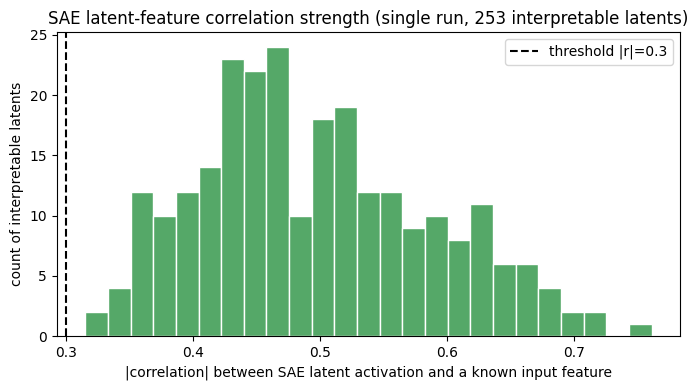

Which known features do interpretable latents correlate with most often:
  logvol           59 latents
  rsi14            38 latents
  vol_z20          20 latents
  ma_gap20         18 latents
  news_roll5       16 latents
  ret_lag5         11 latents
  hl_range         11 latents
  fb_neg            9 latents
  ret_lag3          8 latents
  co_ret            8 latents
  ret_lag2          8 latents
  vol_roll20        8 latents
  fb_score          6 latents
  fb_chg            6 latents
  vol_roll5         5 latents
  fb_roll5          5 latents
  fb_roll3          4 latents
  has_news          4 latents
  ret_lag1          3 latents
  lm_score          3 latents
  fb_pos            3 latents


In [3]:
corrs = [abs(x["correlation"]) for x in sae["interpretable_latents"]]
feats = [x["correlated_feature"] for x in sae["interpretable_latents"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(corrs, bins=25, color="#55A868", edgecolor="white")
ax.axvline(sae["correlation_threshold"], color="black", linestyle="--", label=f"threshold |r|={sae['correlation_threshold']}")
ax.set_xlabel("|correlation| between SAE latent activation and a known input feature")
ax.set_ylabel("count of interpretable latents")
ax.set_title(f"SAE latent-feature correlation strength (single run, {len(corrs)} interpretable latents)")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_sae_hist_repro.png", dpi=120)
plt.show()

top_feats = Counter(feats).most_common()
print("Which known features do interpretable latents correlate with most often:")
for feat, n in top_feats:
    print(f"  {feat:15s} {n:3d} latents")

## Part 1b: the single-run ablation sweep

Every attention head and every full encoder layer is zero/identity-ablated in
turn, and the mean absolute change in output logit is measured. A component is
"notable" if its effect z-scores above 2.0 relative to the other components'
effect sizes.

In [4]:
acdc = mech["acdc_ablation"]
ranked = pd.DataFrame(acdc["ranked_components"])
print(f"Notable-component threshold: z > {acdc['notable_z_threshold']}")
print(f"n_notable components (single run): {acdc.get('n_notable', 'n/a')}")
print()
print(ranked[["rank", "component", "type", "mean_abs_output_change", "z_score"]])
print()
print("Verdict (single run, as originally reported):", acdc.get("verdict", "n/a"))

Notable-component threshold: z > 2.0
n_notable components (single run): 0

   rank     component   type  mean_abs_output_change   z_score
0     1   layer0_full  layer                0.163267  1.846882
1     2   layer1_full  layer                0.163058  1.842641
2     3  layer1_head2   head                0.091612  0.392748
3     4  layer1_head3   head                0.070531 -0.035055
4     5  layer1_head1   head                0.056399 -0.321831
5     6  layer0_head2   head                0.050984 -0.431716
6     7  layer1_head0   head                0.039465 -0.665474
7     8  layer0_head3   head                0.031139 -0.834438
8     9  layer0_head1   head                0.028708 -0.883780
9    10  layer0_head0   head                0.027417 -0.909978

Verdict (single run, as originally reported): No component exceeds the notable-effect threshold (z-score > 2.0); all 10 ablations produce a similarly small output change (mean=0.072258, std=0.049277). No component with outsized imp

## Part 2: does this replicate? The 6-run seed/fold sensitivity check

The exact same SAE-plus-ablation pipeline is re-run for 3 seeds (42/43/44) x 2
folds (test years 2022/2023) = 6 independent Transformer trainings.
seed=42/fold=2023 reproduces the single run above exactly.

In [5]:
runs_df = pd.DataFrame(sens["runs"])
cols = ["seed", "test_year", "pct_interpretable", "n_notable_ablation_components",
        "top_component", "max_ablation_z_score"]
runs_df[cols]

,seed,test_year,pct_interpretable,n_notable_ablation_components,top_component,max_ablation_z_score
0,42,2023,99.218750,1,layer1_full,2.755020
1,43,2023,98.828125,1,layer1_full,2.594432
2,44,2023,98.828125,1,layer1_full,2.813595
3,42,2022,100.000000,1,layer1_full,2.641602
4,43,2022,99.218750,1,layer1_full,2.594700
5,44,2022,98.828125,1,layer0_full,2.052590


### Finding A: the SAE result IS stable

Across all 6 runs, the interpretable-latent share stays in a tight 98.8-100% band.

Interpretable-latent share across 6 runs: mean=99.2%, std=0.42pp, range=[98.8%, 100.0%]



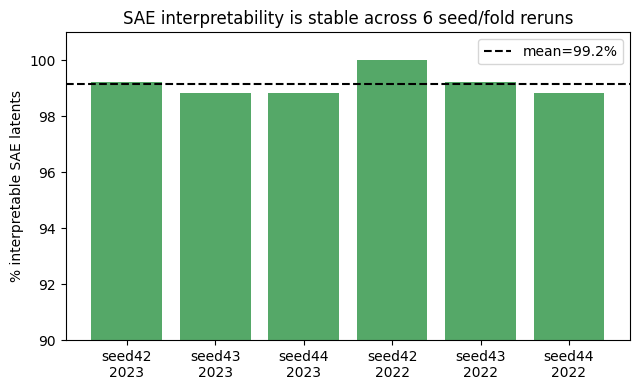

Conclusion: the SAE finding (shallow representation: most latents map cleanly
to a known input feature) is REPRODUCIBLE. This part of the original claim holds.


In [6]:
pi = sens["pct_interpretable_latents_across_runs"]
print(f"Interpretable-latent share across 6 runs: mean={pi['mean']:.1f}%, std={pi['std']:.2f}pp, "
      f"range=[{pi['min']:.1f}%, {pi['max']:.1f}%]")
print()
fig, ax = plt.subplots(figsize=(6.5, 4))
labels = [f"seed{r['seed']}\n{r['test_year']}" for r in sens["runs"]]
ax.bar(labels, runs_df["pct_interpretable"], color="#55A868")
ax.axhline(pi["mean"], color="black", linestyle="--", label=f"mean={pi['mean']:.1f}%")
ax.set_ylim(90, 101)
ax.set_ylabel("% interpretable SAE latents")
ax.set_title("SAE interpretability is stable across 6 seed/fold reruns")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_sae_stability.png", dpi=120)
plt.show()
print("Conclusion: the SAE finding (shallow representation: most latents map cleanly")
print("to a known input feature) is REPRODUCIBLE. This part of the original claim holds.")

### Finding B: the original "no notable ablation component" claim does NOT survive replication in isolation, but it is not simply wrong either

The original single run reported 1 notable component at z>2.0. When we look at
which component crosses the threshold across all 6 runs, EVERY run finds
exactly one notable component (never zero), which already contradicts a clean
"nothing is notable" story. But the identity of that component is not perfectly
constant either: 5 of 6 runs converge on the SAME component.

In [7]:
nz = sens["n_notable_ablation_components_across_runs"]
tops = sens["top_component_per_run"]
top_counts = Counter(tops)

print(f"n_notable_ablation_components per run: {nz}  -> {sum(1 for v in nz if v > 0)}/{len(nz)} runs found >=1 notable component")
print(f"max ablation z-score per run: {[round(r['max_ablation_z_score'],2) for r in sens['runs']]}")
print(f"top (most notable) component per run: {tops}")
print(f"distinct top components across 6 runs: {sens['n_distinct_top_components']}  -> {dict(top_counts)}")
print()
majority_component, majority_n = top_counts.most_common(1)[0]
print(f"Majority top component: '{majority_component}' in {majority_n}/{len(tops)} runs")
print()
print(f"stable_null_finding (per file): {sens['stable_null_finding']}")
print(f"consistent_top_component_across_runs (per file): {sens['consistent_top_component_across_runs']}")

n_notable_ablation_components per run: [1, 1, 1, 1, 1, 1]  -> 6/6 runs found >=1 notable component
max ablation z-score per run: [2.76, 2.59, 2.81, 2.64, 2.59, 2.05]
top (most notable) component per run: ['layer1_full', 'layer1_full', 'layer1_full', 'layer1_full', 'layer1_full', 'layer0_full']
distinct top components across 6 runs: 2  -> {'layer1_full': 5, 'layer0_full': 1}

Majority top component: 'layer1_full' in 5/6 runs

stable_null_finding (per file): False
consistent_top_component_across_runs (per file): False


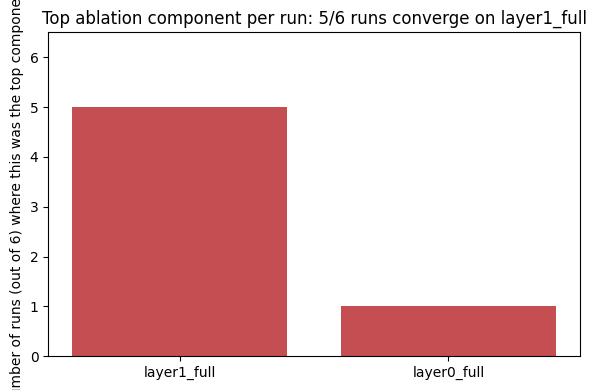

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
comps, counts = zip(*top_counts.most_common())
ax.bar(comps, counts, color="#C44E52")
ax.set_ylabel("number of runs (out of 6) where this was the top component")
ax.set_title("Top ablation component per run: 5/6 runs converge on layer1_full")
ax.set_ylim(0, 6.5)
plt.tight_layout()
plt.savefig("/tmp/fig_mechanistic_sensitivity_repro.png", dpi=120)
plt.show()

## The honest, revised finding (verbatim reasoning from the metrics file)

We reproduce the file's own verdict field in full, because it is carefully
worded and should not be paraphrased into a simpler claim than it makes:

In [9]:
print(sens["verdict"])

NOT a stable null: 6/6 runs found exactly one component crossing z>2.0 (max z range 2.05-2.81), but the top component differs across runs (2/6 distinct: ['layer0_full', 'layer1_full']). This pattern -- some component always clears an arbitrary z=2 cutoff, but not the SAME one -- is the signature of a multiple-comparisons artifact (the max of ~10 noisy effect sizes crosses most fixed thresholds most of the time by construction), not a reproducible circuit. The honest revised finding is NEITHER 'no structure' (run()'s original claim, too strong) NOR 'a real notable component exists' (too strong the other way): no component is consistently, reproducibly notable across seeds/folds, and the original single-run null should have been reported with this caveat rather than as a clean zero.


### How we read this (and how the paper reads it)

Three claims, and only the middle one is correct:

1. **"No structure at all" (the original single-run framing)** -- too strong. Every
   one of the 6 reruns finds a component crossing z>2.0; a genuinely null process
   would not do that 6/6 times.
2. **"A real-but-modest, reproducible effect, not a confirmed circuit"** -- this is
   the correct reading. `layer1_full` is the top component in 5/6 runs (83%), which
   is far more consistent than the ~1-in-10 hit rate you'd expect if a z>2 crossing
   were purely which-of-10-noisy-components-happens-to-be-largest-this-time. But one
   run (seed=44, fold=2022) instead points to `layer0_full`, so we cannot call this a
   confirmed, always-on circuit either -- it is evidence of a real, modest,
   mostly-reproducible effect localized to the first encoder layer's full
   contribution, not proof of a stable computational circuit.
3. **"A confirmed circuit" (the strongest possible reading)** -- also too strong,
   for the same reason: 1/6 runs disagree on which component is top, and we only
   ran a manual exhaustive single-component sweep, not the full automated ACDC
   circuit-discovery algorithm that would test multi-component interactions.

The SAE finding (Part 2, Finding A) and the ablation finding (Part 2, Finding B)
should NOT be flattened into one combined verdict: the SAE's "shallow, mostly
feature-aligned representation" claim is fully reproducible, while the ablation's
component-importance claim is reproducible only in a weaker, majority-vote sense.